In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import lpips
from sklearn.model_selection import train_test_split

import os
import sys
sys.path.append(os.path.abspath('..'))

from vae.vq_vae import TinnyVQVAE
from vqgan import PatchDiscriminator, hinge_d_loss, hinge_g_loss
from utils.utils import reconstruct, return_device, return_photos

In [2]:
device = return_device()

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../../archive/lfw-deepfunneled'

all_photos = return_photos(PATH_TO_PHOTOS)

100%|██████████| 13233/13233 [00:12<00:00, 1049.91it/s]

Photos uploaded: 13233


In [4]:
batch_size=64

train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=batch_size)

# VQ-GAN

Generator = VQ-VAE (normalized codebook). Discriminator = PatchGAN. Codebook is initialized from real encoder outputs.

A VQ-VAE trained with two extra losses on top of reconstruction + VQ:
- **LPIPS** (perceptual) - matches deep features, not just pixels, so results stop being blurry.
- **Adversarial** (PatchGAN) - a discriminator judges local patches, pushing realistic texture.

The generator is reused as-is from `vq_vae.py` (`TinnyVQVAE`), only the discriminator and the GAN losses are new. This is the perceptual + adversarial upgrade that closes the quality gap of the plain VQ-VAE.

In [6]:
modelG = TinnyVQVAE(n_e=1024, e_dim=8, use_ema=False, normalize=True).to(device)
modelD = PatchDiscriminator().to(device)

optimizerG = torch.optim.Adam(modelG.parameters(), lr=1e-3, betas=(0.5, 0.9))
optimizerD = torch.optim.Adam(modelD.parameters(), lr=1e-4, betas=(0.5, 0.9))

lpips_fn = lpips.LPIPS(net='vgg').to(device)

modelG.eval()
with torch.no_grad():
    sample = next(iter(train_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    z_e, _ = modelG.encode(sample)
    perm = torch.randperm(z_e.shape[0])[:modelG.quantize.n_e]
    modelG.quantize.init_from_data(z_e[perm])
print('Codebook initialized from data')

# The adversarial loss only switches on after `disc_start_epoch` - the autoencoder first learns to reconstruct, 
# then the discriminator starts refining texture (otherwise it overwhelms early training). 
# G loss = MSE + VQ + LPIPS + lambda * adversarial.

n_epochs = 50
disc_start_epoch = 5  # epochs of pure recon + vq + lpips before the GAN kicks in
lambda_adv = 0.01  # weight of the adversarial term
d_every = 5  # update the discriminator once every d_every iterations (lets G catch up)

loss_MSE, loss_VQ, loss_LPIPS, loss_G_adv, loss_D = [], [], [], [], []

step = 0
for epoch in tqdm(range(n_epochs)):
    modelG.train()
    modelD.train()
    use_gan = epoch >= disc_start_epoch
    for batch in train_loader:
        real = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255  # [0,1]
        recon, vq_loss = modelG(real)

        if use_gan and step % d_every == 0:
            modelD.zero_grad()
            d_real = modelD(real)
            d_fake = modelD(recon.detach())
            d_loss = hinge_d_loss(d_real, d_fake)
            d_loss.backward()
            optimizerD.step()
            loss_D.append(d_loss.item())

        modelG.zero_grad()
        mse = F.mse_loss(recon, real)
        percep = lpips_fn(recon * 2 - 1, real * 2 - 1).mean()  # lpips expects [-1,1]
        g_loss = mse + vq_loss + percep
        if use_gan:
            g_adv = hinge_g_loss(modelD(recon))
            g_loss = g_loss + lambda_adv * g_adv
            loss_G_adv.append(g_adv.item())
        g_loss.backward()
        optimizerG.step()

        loss_MSE.append(mse.item())
        loss_VQ.append(vq_loss.item())
        loss_LPIPS.append(percep.item())

        step += 1

torch.save(modelG.state_dict(), '../checkpoints/vqgan_reconstruct.pt')

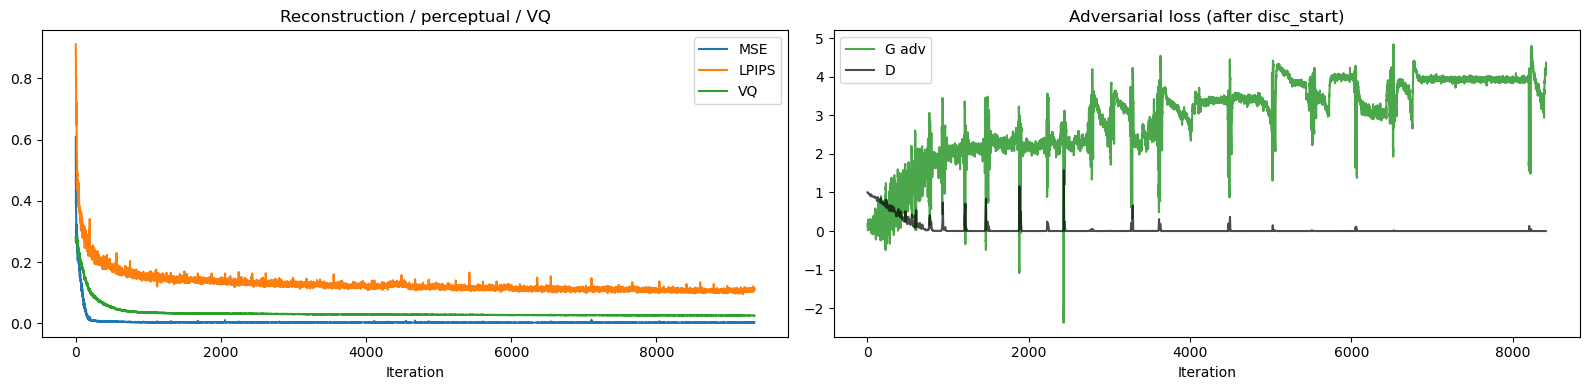

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.plot(loss_MSE, label='MSE')
ax1.plot(loss_LPIPS, label='LPIPS')
ax1.plot(loss_VQ, label='VQ')
ax1.legend()
ax1.set_xlabel('Iteration')
ax1.set_title('Reconstruction / perceptual / VQ')

ax2.plot(loss_G_adv, label='G adv', color='green', alpha=0.7)
ax2.plot(np.arange(len(loss_D)) * d_every, loss_D, label='D', color='black', alpha=0.7)

ax2.legend()
ax2.set_xlabel('Iteration')
ax2.set_title('Adversarial loss (after disc_start)')

plt.tight_layout()
plt.show()

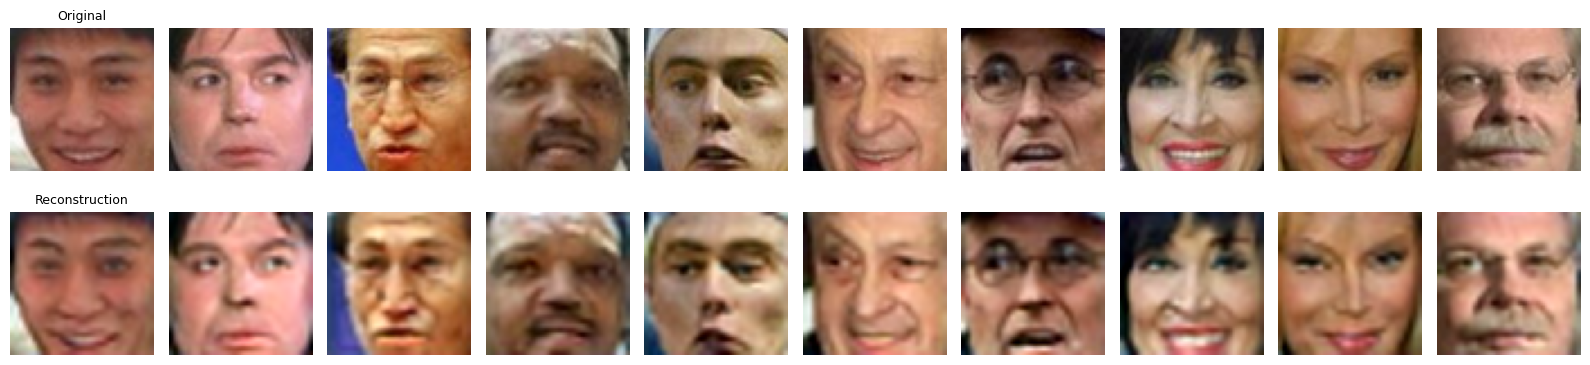

In [8]:
reconstruct(modelG, val_loader, device)

To turn VQ-GAN into a *generative* model, we should train a transformer prior on its codes exactly as in the VQ-VAE notebook